In [73]:
import pandas as pd
import numpy as np
import glob
import os
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import os


In [74]:
DATA_DIR = Path("../data/eye_tracking")

In [75]:
csv_files = sorted(DATA_DIR.glob("*.csv"))
print(csv_files[:3])

[PosixPath('../data/eye_tracking/01_ET_Data_2026-02-19.csv'), PosixPath('../data/eye_tracking/02_ET_Data_2026-03-10.csv')]


In [76]:
file_path = csv_files[1]  # Christian on-boarding

df = pd.read_csv(file_path, low_memory=False)

# extract participant_id from filename
participant_id = file_path.name[:2]
df["participant_id"] = participant_id

print(df.shape)

(384510, 61)


In [77]:
def cleaning_function(df: pd.DataFrame) -> pd.DataFrame:
    """
    Preprocess eye-tracking data for analysis.

    Steps:

       - remove training models (TM) and NaN
 ......
    """

    df = df.copy()

    mask = (
        df["model_name"].notna() &
        (~df["model_name"].str.contains("TM", na=False))
    )
    df = df.loc[mask].copy()


    return df

In [78]:
df_clean = cleaning_function(df)

In [79]:
def add_time_per_model(df, time_col: str = "gaze_capture_time"):
    """
    Add time_ms per model_name, respecting experiment order.

    Sorting:
    condition_number → trial_number → time

    Assumes:
    - time_col is in nanoseconds
    - df contains: model_name, condition_number, trial_number
    """

    df = df.copy()

    # correct ordering of experiment
    df = df.sort_values(["condition_number", "trial_number", time_col])

    # compute relative time per model
    t0 = df.groupby("model_name")[time_col].transform("first")

    df["time_ms"] = (df[time_col] - t0) / 1_000_000.0

    return df

In [93]:
df_clean = add_time_per_model(df_clean, time_col="gaze_capture_time")

In [94]:
df_clean

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,object_position_x,object_position_y,object_position_z,object_rotation_x,object_rotation_y,object_rotation_z,object_rotation_w,participant_id,time_ms,angular_velocity
44844,1000325694741666500,1773141240816,336.4777,0.975025,584492,0.821958,Valid,0.013115,0.144055,0.989483,...,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,0.0000,NaN
44845,1000325694746666700,1773141240816,336.4777,0.977628,584493,0.817059,Valid,0.013078,0.144172,0.989466,...,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,5.0002,1.420650
44846,1000325694751663700,1773141240816,336.4777,0.980051,584494,0.827888,Valid,0.013039,0.144279,0.989451,...,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,9.9972,1.307756
44847,1000325694756664500,1773141240816,336.4777,0.982777,584495,0.820999,Valid,0.013003,0.144336,0.989443,...,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,14.9980,0.791661
44848,1000325694761666200,1773141240824,336.4866,0.985244,584496,0.822582,Valid,0.012964,0.144379,0.989437,...,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,19.9997,0.664515
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
381611,1000328169625686100,1773143715702,1593.0000,0.677271,1079278,0.281021,Valid,0.285666,-0.076886,0.955240,...,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97592.3892,37.569699
381612,1000328169630684400,1773143715702,1593.0000,0.681785,1079279,0.310471,Valid,0.287534,-0.074987,0.954831,...,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97597.3875,30.886675
381613,1000328169635683800,1773143715702,1593.0000,0.681963,1079280,0.328037,Valid,0.288786,-0.073097,0.954599,...,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97602.3869,26.124483
381614,1000328169640683200,1773143715702,1593.0000,0.681368,1079281,0.382888,Valid,0.289915,-0.071516,0.954377,...,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97607.3863,22.406689


In [81]:
def add_angular_velocity(df, time_col="gaze_capture_time"):
    """
    Compute gaze angular velocity (deg/s) from Varjo gaze_forward vectors.

    Method
    ------
    1. Take consecutive 3D gaze direction vectors.
    2. Compute the angle between them with:
           angle = atan2(||g_prev x g_curr||, g_prev · g_curr)
       This is numerically stable.
    3. Divide by the time difference in seconds.
    4. Convert from rad/s to deg/s.

    Assumptions
    -----------
    - gaze_forward_x/y/z describe gaze direction.
    - time_col is in nanoseconds.
    - Velocity should be computed within each participant/model block.

    Returns
    -------
    df : copy of input dataframe with a new column:
         - angular_velocity
    """
    df = df.copy()

    # Sort so consecutive rows are truly consecutive in time
    df = df.sort_values(
        ["condition_number", "trial_number", time_col]
    )

    # Initialize output column
    df["angular_velocity"] = np.nan

    # Compute separately within each continuous block
    for (_, _), sub in df.groupby(["condition_number", "trial_number"], sort=False):
        idx = sub.index

        # Extract gaze direction vectors
        g = sub[[
            "gaze_forward_x",
            "gaze_forward_y",
            "gaze_forward_z"
        ]].to_numpy(dtype=float)

        # Normalize vectors just in case they are not perfectly unit length
        norms = np.linalg.norm(g, axis=1, keepdims=True)
        g = g / np.clip(norms, 1e-12, None)

        # Previous and current vectors
        g_prev = g[:-1]
        g_curr = g[1:]

        # Angle between consecutive vectors:
        # angle = atan2(||cross||, dot)
        cross_norm = np.linalg.norm(np.cross(g_prev, g_curr), axis=1)
        dot_prod = np.sum(g_prev * g_curr, axis=1)
        angles_rad = np.arctan2(cross_norm, dot_prod)

        # Time difference in seconds (timestamps are in nanoseconds)
        t = sub[time_col].to_numpy(dtype=np.int64)
        dt = np.diff(t) * 1e-9

        # Prepare output for this block
        vel = np.full(len(sub), np.nan)

        # Only compute where dt is valid
        valid = dt > 0
        vel[1:][valid] = np.degrees(angles_rad[valid] / dt[valid])

        # Write back into dataframe
        df.loc[idx, "angular_velocity"] = vel

    return df

In [82]:
df_clean = add_angular_velocity(df_clean, time_col="gaze_capture_time")

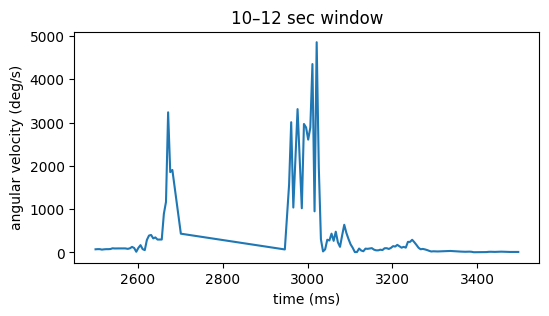

In [90]:
sub = df_clean[
    (df_clean["condition_number"] == 2) &
    (df_clean["trial_number"] == 2) &
    (df_clean["time_ms"] >= 2500) &   # 2.5 sec
    (df_clean["time_ms"] <= 3500)     # 3.5 sec
].copy()

plt.figure(figsize=(6,3))
plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.title("10–12 sec window")
plt.show()

In [88]:
df_clean["gaze_forward_x"].min()

np.float64(-0.9084389)

In [89]:
df_clean["gaze_forward_x"].max()


np.float64(0.6763899)

In [83]:
df_clean

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,object_position_x,object_position_y,object_position_z,object_rotation_x,object_rotation_y,object_rotation_z,object_rotation_w,participant_id,time_ms,angular_velocity
44844,1000325694741666500,1773141240816,336.4777,0.975025,584492,0.821958,Valid,0.013115,0.144055,0.989483,...,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,0.0000,NaN
44845,1000325694746666700,1773141240816,336.4777,0.977628,584493,0.817059,Valid,0.013078,0.144172,0.989466,...,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,5.0002,1.420650
44846,1000325694751663700,1773141240816,336.4777,0.980051,584494,0.827888,Valid,0.013039,0.144279,0.989451,...,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,9.9972,1.307756
44847,1000325694756664500,1773141240816,336.4777,0.982777,584495,0.820999,Valid,0.013003,0.144336,0.989443,...,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,14.9980,0.791661
44848,1000325694761666200,1773141240824,336.4866,0.985244,584496,0.822582,Valid,0.012964,0.144379,0.989437,...,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,19.9997,0.664515
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
381611,1000328169625686100,1773143715702,1593.0000,0.677271,1079278,0.281021,Valid,0.285666,-0.076886,0.955240,...,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97592.3892,37.569699
381612,1000328169630684400,1773143715702,1593.0000,0.681785,1079279,0.310471,Valid,0.287534,-0.074987,0.954831,...,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97597.3875,30.886675
381613,1000328169635683800,1773143715702,1593.0000,0.681963,1079280,0.328037,Valid,0.288786,-0.073097,0.954599,...,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97602.3869,26.124483
381614,1000328169640683200,1773143715702,1593.0000,0.681368,1079281,0.382888,Valid,0.289915,-0.071516,0.954377,...,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97607.3863,22.406689


In [43]:
df_clean["angular_velocity"].describe()

count    202951.000000
mean         48.197764
std         170.719307
min           0.009793
25%           5.700849
50%          13.973341
75%          35.573098
max        9431.987025
Name: angular_velocity, dtype: float64

In [44]:
df_clean["angular_velocity"].info()

<class 'pandas.core.series.Series'>
Index: 202969 entries, 44844 to 381615
Series name: angular_velocity
Non-Null Count   Dtype  
--------------   -----  
202951 non-null  float64
dtypes: float64(1)
memory usage: 11.2 MB


## Plot distribution (log scale!)

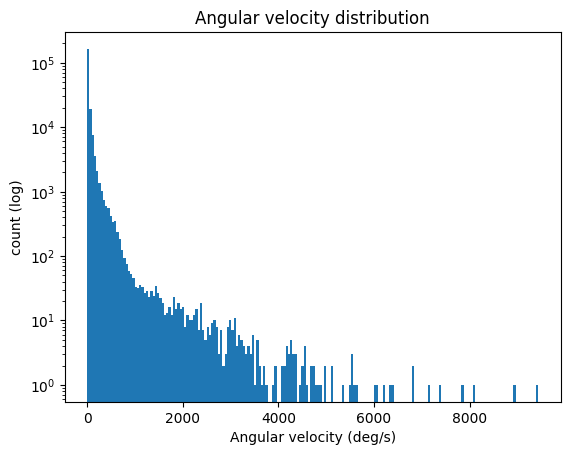

In [84]:
plt.hist(df_clean["angular_velocity"], bins=200)
plt.yscale("log")
plt.xlabel("Angular velocity (deg/s)")
plt.ylabel("count (log)")
plt.title("Angular velocity distribution")
plt.show()

In [91]:
df_clean["angular_velocity"].max()

np.float64(9431.987025217624)

## Time-series Check

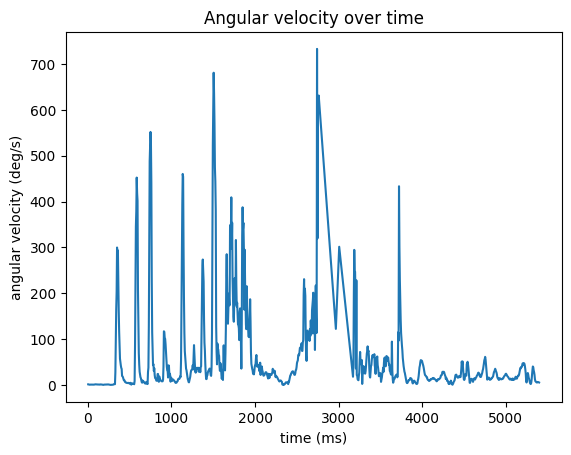

In [85]:
sub = df_clean[df_clean["participant_id"] == "02"].iloc[:1000]

plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.title("Angular velocity over time")
plt.show()

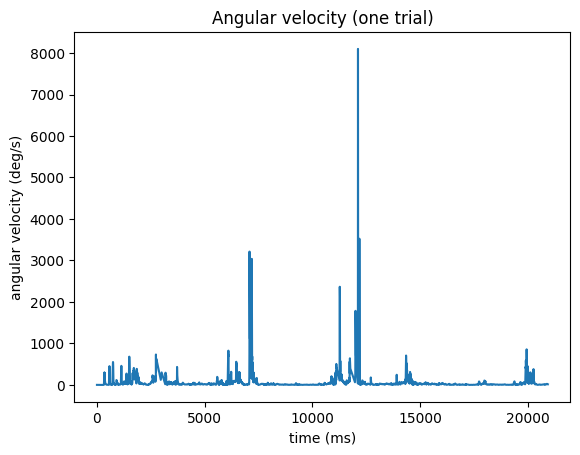

In [92]:
sub = df_clean[
    (df_clean["condition_number"] == 1) &
    (df_clean["trial_number"] == 1)
].copy()

# sort (important!)
sub = sub.sort_values("gaze_capture_time")

plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.title("Angular velocity (one trial)")
plt.show()

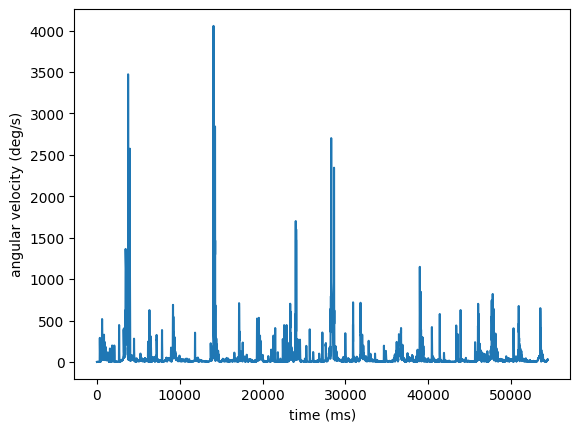

In [48]:
sub = df_clean[
    (df_clean["condition_number"] == 2) &
    (df_clean["trial_number"] == 1)
].copy()

sub = sub.sort_values("gaze_capture_time")

plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.show()

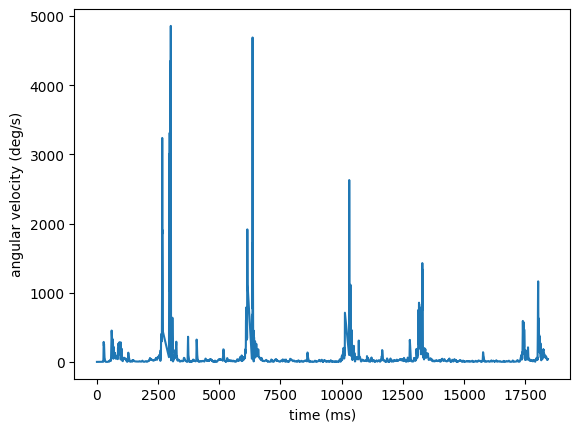

In [49]:
sub = df_clean[
    (df_clean["condition_number"] == 2) &
    (df_clean["trial_number"] == 2)
].copy()

sub = sub.sort_values("gaze_capture_time")

plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.show()

In [50]:
# find extreme points
spikes = sub[sub["angular_velocity"] > 2000]

# pick one spike
i = spikes.index[0]

# take small window around it
window = sub.loc[i-5:i+5].copy()

window[[
    "time_ms",
    "gaze_capture_time",
    "angular_velocity",
    "gaze_forward_x",
    "gaze_forward_y",
    "gaze_forward_z"
]]

,time_ms,gaze_capture_time,angular_velocity,gaze_forward_x,gaze_forward_y,gaze_forward_z
207592,2641.3360,1000326925556781700,347.075613,-0.231893,0.072707,0.970020
207593,2646.3335,1000326925561779200,297.482298,-0.256778,0.068435,0.964044
207594,2656.3347,1000326925571780400,298.347488,-0.280610,0.022355,0.959561
207595,2661.3358,1000326925576781500,891.878701,-0.212975,-0.011985,0.976984
207596,2666.3430,1000326925581788700,1167.716432,-0.113437,-0.027326,0.993169
207597,2671.3436,1000326925586789300,3237.520757,-0.175517,-0.296575,0.938742
207598,2676.3437,1000326925591789400,1855.817741,-0.035894,-0.377197,0.925437
207599,2681.3448,1000326925596790500,1905.876387,0.099029,-0.463240,0.880682
207600,2701.3486,1000326925616794300,433.091101,-0.031565,-0.396767,0.917376
207601,2946.3730,1000326925861818700,68.881033,-0.066556,-0.114849,0.991151


In [51]:
dt = window["gaze_capture_time"].diff() * 1e-9
print(dt)

207592         NaN
207593    0.004998
207594    0.010001
207595    0.005001
207596    0.005007
207597    0.005001
207598    0.005000
207599    0.005001
207600    0.020004
207601    0.245024
207602    0.009997
Name: gaze_capture_time, dtype: float64


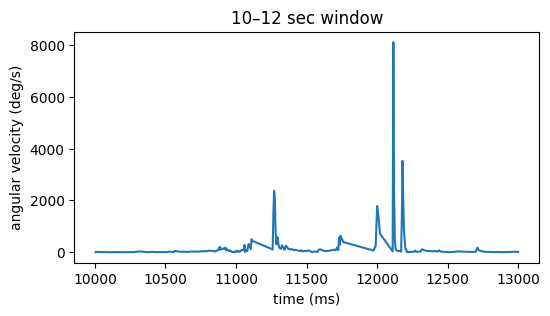

In [54]:
sub = df_clean[
    (df_clean["condition_number"] == 1) &
    (df_clean["trial_number"] == 1) &
    (df_clean["time_ms"] >= 10000) &   # 10 sec
    (df_clean["time_ms"] <= 13000)     # 12 sec
].copy()

plt.figure(figsize=(6,3))
plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.title("10–12 sec window")
plt.show()

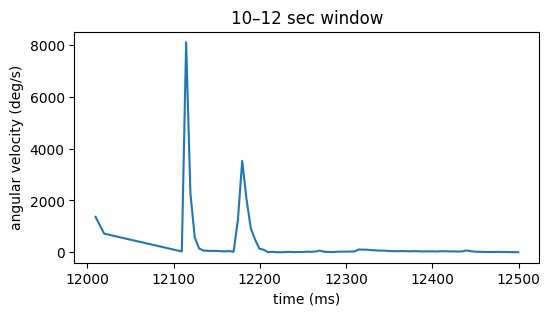

In [55]:
sub = df_clean[
    (df_clean["condition_number"] == 1) &
    (df_clean["trial_number"] == 1) &
    (df_clean["time_ms"] >= 12000) &   # 10 sec
    (df_clean["time_ms"] <= 12500)     # 12 sec
].copy()

plt.figure(figsize=(6,3))
plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.title("10–12 sec window")
plt.show()

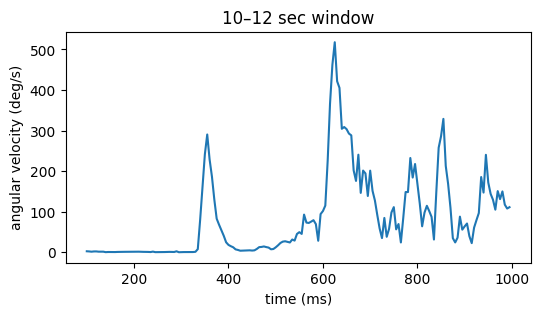

In [63]:
sub = df_clean[
    (df_clean["condition_number"] == 2) &
    (df_clean["trial_number"] == 1) &
    (df_clean["time_ms"] >= 100) &   # 10 sec
    (df_clean["time_ms"] <= 1000)     # 12 sec
].copy()

plt.figure(figsize=(6,3))
plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.title("10–12 sec window")
plt.show()

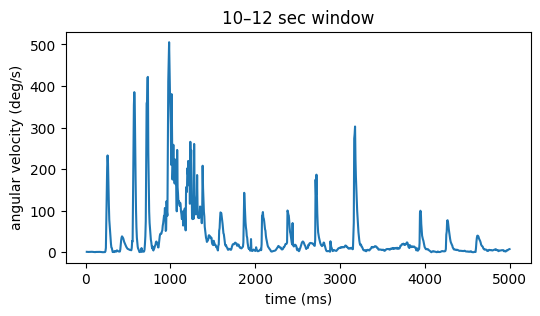

In [68]:
sub = df_clean[
    (df_clean["condition_number"] == 2) &
    (df_clean["trial_number"] == 5) &
    (df_clean["time_ms"] >= 10) &   # 10 sec
    (df_clean["time_ms"] <= 5000)     # 12 sec
].copy()

plt.figure(figsize=(6,3))
plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.title("10–12 sec window")
plt.show()

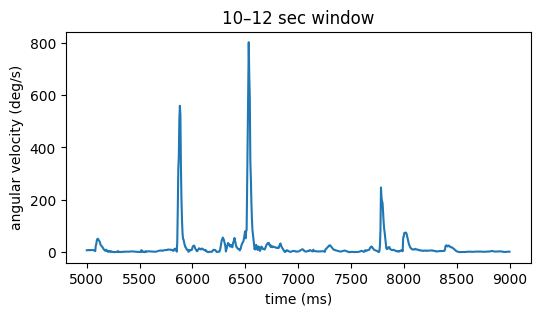

In [69]:
sub = df_clean[
    (df_clean["condition_number"] == 2) &
    (df_clean["trial_number"] == 5) &
    (df_clean["time_ms"] >= 5000) &   # 10 sec
    (df_clean["time_ms"] <= 9000)     # 12 sec
].copy()

plt.figure(figsize=(6,3))
plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.title("10–12 sec window")
plt.show()

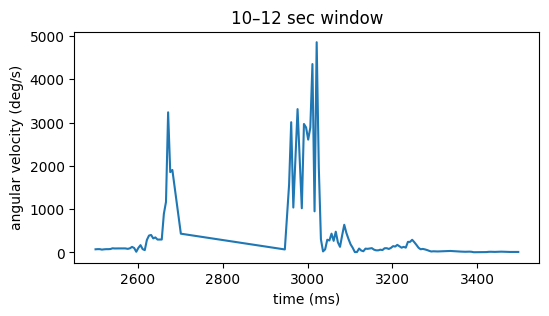

In [87]:
sub = df_clean[
    (df_clean["condition_number"] == 2) &
    (df_clean["trial_number"] == 2) &
    (df_clean["time_ms"] >= 2500) &   # 10 sec
    (df_clean["time_ms"] <= 3500)     # 12 sec
].copy()

plt.figure(figsize=(6,3))
plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.title("10–12 sec window")
plt.show()

In [ ]:
def get_time_window(df, cond, trial, t_start_ms, t_end_ms):
    return df[
        (df["condition_number"] == cond) &
        (df["trial_number"] == trial) &
        (df["time_ms"] >= t_start_ms) &
        (df["time_ms"] <= t_end_ms)
    ].copy()

In [60]:
dt = np.diff(sub["gaze_capture_time"])
print(dt.min())

4976500


In [10]:
def add_angular_velocity_transcorr(df, time_col="gaze_capture_time"):
    """
    Add Debora-style angular velocity (deg/s) adapted for Varjo data.

    Uses:
    - gaze_origin_* and gaze_forward_* from Varjo
    - focus_distance
    - hmd_position_* and hmd_rotation_* to move from head coordinates to world coordinates

    Returns a copy of df with a new column:
    - angular_vel_tc
    """
    import numpy as np
    import pandas as pd

    df = df.copy()

    # sort in experiment order
    df = df.sort_values(
        ["participant_id", "condition_number", "trial_number", time_col]
    )

    df["angular_vel_tc"] = np.nan

    def rotate_vecs_by_quat(v, q):
        """
        Rotate Nx3 vectors v by Nx4 quaternions q = [x, y, z, w].
        """
        q_xyz = q[:, :3]
        q_w = q[:, 3:4]

        # t = 2 * cross(q_xyz, v)
        t = 2.0 * np.cross(q_xyz, v)

        # v' = v + w*t + cross(q_xyz, t)
        return v + q_w * t + np.cross(q_xyz, t)

    group_cols = ["participant_id", "model_name"]

    for _, sub in df.groupby(group_cols, sort=False):
        idx = sub.index

        # local gaze origin (head-relative)
        origin_local = sub[
            ["gaze_origin_x", "gaze_origin_y", "gaze_origin_z"]
        ].to_numpy(dtype=float)

        # local gaze forward (head-relative)
        forward_local = sub[
            ["gaze_forward_x", "gaze_forward_y", "gaze_forward_z"]
        ].to_numpy(dtype=float)

        # normalize forward
        forward_norm = np.linalg.norm(forward_local, axis=1, keepdims=True)
        forward_local = forward_local / np.clip(forward_norm, 1e-12, None)

        # HMD world pose
        hmd_pos = sub[
            ["hmd_position_x", "hmd_position_y", "hmd_position_z"]
        ].to_numpy(dtype=float)

        quat = sub[
            ["hmd_rotation_x", "hmd_rotation_y", "hmd_rotation_z", "hmd_rotation_w"]
        ].to_numpy(dtype=float)

        # rotate local gaze origin/forward into world coordinates
        origin_world = rotate_vecs_by_quat(origin_local, quat) + hmd_pos
        forward_world = rotate_vecs_by_quat(forward_local, quat)

        # normalize again after rotation
        forward_world = forward_world / np.clip(
            np.linalg.norm(forward_world, axis=1, keepdims=True), 1e-12, None
        )

        # reconstruct hitpoint like hpoo
        dist = sub["focus_distance"].to_numpy(dtype=float).reshape(-1, 1)
        hit_world = origin_world + dist * forward_world

        # Δh = consecutive hitpoint displacement
        delta_h = np.full_like(hit_world, np.nan)
        delta_h[1:] = hit_world[1:] - hit_world[:-1]

        # gaze direction g(t)
        gaze_vec = hit_world - origin_world
        gaze_vec = gaze_vec / np.clip(
            np.linalg.norm(gaze_vec, axis=1, keepdims=True), 1e-12, None
        )

        # remove component along gaze direction
        proj_scalar = np.sum(delta_h * gaze_vec, axis=1, keepdims=True)
        proj_vec = proj_scalar * gaze_vec
        delta_h_perp = delta_h - proj_vec

        v_gaze_inplane = np.linalg.norm(delta_h_perp, axis=1)

        # eye-to-hitpoint distance
        sub_hpoo = np.linalg.norm(hit_world - origin_world, axis=1)

        # angle in radians
        theta = np.arctan2(v_gaze_inplane, sub_hpoo)

        # dt in seconds
        t = sub[time_col].to_numpy(dtype=np.int64)
        dt = np.full(len(sub), np.nan)
        dt[1:] = np.diff(t) * 1e-9

        # angular velocity in deg/s
        vel = np.full(len(sub), np.nan)
        valid = (dt > 0) & np.isfinite(theta)
        vel[valid] = np.degrees(theta[valid] / dt[valid])

        df.loc[idx, "angular_vel_tc"] = vel

    return df

In [11]:
df_clean = add_angular_velocity_transcorr(df_clean, time_col="gaze_capture_time")

In [12]:
df_clean

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,object_position_x,object_position_y,object_position_z,object_rotation_x,object_rotation_y,object_rotation_z,object_rotation_w,participant_id,time_ms,angular_vel_tc
44844,1000325694741666500,1773141240816,336.4777,0.975025,584492,0.821958,Valid,0.013115,0.144055,0.989483,...,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,0.0000,NaN
44845,1000325694746666700,1773141240816,336.4777,0.977628,584493,0.817059,Valid,0.013078,0.144172,0.989466,...,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,5.0002,1.416867
44846,1000325694751663700,1773141240816,336.4777,0.980051,584494,0.827888,Valid,0.013039,0.144279,0.989451,...,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,9.9972,1.304523
44847,1000325694756664500,1773141240816,336.4777,0.982777,584495,0.820999,Valid,0.013003,0.144336,0.989443,...,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,14.9980,0.789465
44848,1000325694761666200,1773141240824,336.4866,0.985244,584496,0.822582,Valid,0.012964,0.144379,0.989437,...,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,19.9997,3.224694
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
381611,1000328169625686100,1773143715702,1593.0000,0.677271,1079278,0.281021,Valid,0.285666,-0.076886,0.955240,...,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97592.3892,37.132585
381612,1000328169630684400,1773143715702,1593.0000,0.681785,1079279,0.310471,Valid,0.287534,-0.074987,0.954831,...,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97597.3875,30.682067
381613,1000328169635683800,1773143715702,1593.0000,0.681963,1079280,0.328037,Valid,0.288786,-0.073097,0.954599,...,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97602.3869,26.117603
381614,1000328169640683200,1773143715702,1593.0000,0.681368,1079281,0.382888,Valid,0.289915,-0.071516,0.954377,...,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97607.3863,22.426189
